# RamanBench — Reproducing the Full Benchmark

This notebook is the complete guide for reproducing the paper benchmark results from scratch — from environment setup to the final leaderboard.

## What the benchmark measures

Each of the 29 models is trained and evaluated on every (dataset, target) combination
across 3 random seeds.  Many datasets contain multiple regression targets, so the actual
number of evaluated keys is larger than the number of raw datasets.

| Dimension | Count |
|---|---|
| Models | 29 — traditional ML, deep learning, tabular foundation, Raman-specific, AutoML |
| Datasets | 77 — 56 regression, 21 classification |
| (Dataset, target) keys | ~171 |
| Seeds | 3 |
| **Total (model, key, seed) triples** | **~14 900** |

## Ecosystem

| Resource | Link |
|---|---|
| **raman-data** (datasets) | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/) |
| **raman-bench** (this package) | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **AutoGluon fork** | [GitHub](https://github.com/mario-koddenbrock/autogluon) |
| **Live Leaderboard** | [HuggingFace Space](https://huggingface.co/spaces/HTW-KI-Werkstatt/RamanBench) |
| **Paper** | [arXiv TBD](https://arxiv.org/abs/TBD) |

## 1 — Prerequisites

The full benchmark requires a **patched AutoGluon fork** that fixes two limitations of the standard AutoGluon 1.5 release:

1. **500-feature cap** — AutoGluon silently skips tabular foundation models (TabPFN v2, TabICL, TabDPT, MITRA) on datasets with more than 500 features. Raman spectra typically have 500–4000 wavenumber points. The fork removes this cap.
2. **TabICL v1 → v2** — AutoGluon 1.5 ships TabICL v1 (classification only). The fork upgrades to v2, which adds regression support. This is expected to be resolved in AutoGluon 1.6.

**Install order matters** — the fork must be installed *before* `raman-bench`, otherwise pip will replace it with the official release.

In [1]:
# Step 1 — AutoGluon fork (must come before raman-bench)

# Option A — install from GitHub (~10 min)
# !pip install -r https://raw.githubusercontent.com/ml-lab-htw/RamanBench/main/requirements-autogluon-fork.txt

# Option B — install from a local clone
# Each -e flag must be repeated — they are separate packages
# FORK=/path/to/autogluon_fork
# !pip install -e $FORK/common -e $FORK/core -e $FORK/features -e $FORK/tabular

# Step 2 — raman-bench with ALL extras (includes torch, tabpfn, ramanspy, …)
# Quotes are required around .[full] — zsh treats unquoted brackets as glob patterns
# !pip install -e ".[full]"          # from inside the RamanBench directory
# !pip install -e "/path/to/RamanBench[full]"  # from anywhere

# Step 3 — datasets
# !pip install raman-data

After installing, verify that the fork is active and TabICL v2 is available.
If TabICL v2 shows as unavailable, the standard AutoGluon release was installed instead of the fork.

In [2]:
import autogluon.tabular
print("AutoGluon version:", autogluon.tabular.__version__)

try:
    from autogluon.tabular.models import TabICLModel
    print("TabICL v2:         available ✓")
except ImportError:
    print("TabICL v2:         NOT available — check fork install")

AutoGluon version: 1.5.1b20260428
TabICL v2:         available ✓


## 2 — Benchmark configuration

The benchmark is driven by a JSON config file.  It specifies which datasets and models to
run, how many seeds to use, the AutoGluon time limit per (model, dataset, seed) triple,
and where to write results.  The cell below loads the paper config and summarises its scope.

In [3]:
import os, json
from raman_bench.config import load_config
from raman_bench.benchmark import configure_benchmark

# Notebooks run with CWD = notebooks/ — step up to the repo root so that
# relative paths like configs/ and scripts/ resolve correctly.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

cfg = load_config("configs/benchmark_v0.1.json")
cfg.setdefault("random_state", 0)  # normally injected per seed by the pipeline
bm  = configure_benchmark(cfg)

n_keys    = len(bm)
n_models  = len(cfg["models"])
n_seeds   = cfg["n_repetitions"]
time_h    = cfg["autogluon_time_limit"] // 3600

print(f"Models:      {n_models} — {', '.join(cfg['models'][:6])}, ...")
print(f"Keys:        {n_keys}  (dataset × target combinations)")
print(f"Seeds:       {n_seeds}")
print(f"Triples:     {n_models * n_keys * n_seeds}")
print(f"Time limit:  {time_h} h per (model, key, seed)")
print(f"Output dir:  {cfg['output_dir']}")

2026-04-28 10:53:23,207 INFO raman_bench.benchmark:__init__:155: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 38665.66it/s]

Models:      29 — ARSENAL, CAT, COATNET, DEEPCNN, DUMMY, FASTAI, ...
Keys:        171  (dataset × target combinations)
Seeds:       3
Triples:     14877
Time limit:  4 h per (model, key, seed)
Output dir:  results/benchmark_v0.1


## 3 — Local test run

Before submitting to the cluster, verify the full pipeline end-to-end with a small
subset.  The `debug.json` config runs just 2 dataset keys and 1 seed, so it completes
in about a minute.  The output is a prediction CSV per (model, key) which is exactly
what the full run produces at scale.

In [4]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "scripts/run_benchmark.py",
     "--config", "configs/debug.json",
     "--model",  "PLS",
     "--step",   "predictions"],
    capture_output=True, text=True
)
print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])

In [5]:
# Inspect what was written
import pandas as pd
from pathlib import Path

debug_cfg = json.load(open("configs/debug.json"))
pred_dir  = Path(debug_cfg["output_dir"]) / "seed_0" / "predictions"

files = sorted(pred_dir.glob("*.csv"))
print(f"{len(files)} prediction file(s) written to {pred_dir}")
if files:
    df = pd.read_csv(files[0])
    print(f"\nExample — {files[0].name}:")
    print(df.head())

4 prediction file(s) written to results/debug/seed_0/predictions

Example — amino_acids_glycine_0_PLS_predictions.csv:
   spectrum_id    target
0            2  5.756146
1            7  6.121722
2            8  6.493736
3           13  6.903412
4           16  5.151103


## 4 — Full benchmark on a SLURM cluster

The full run is submitted as a single SLURM job per condition.  All models and all seeds
run sequentially within that job.  Each prediction file is written as soon as its
(model, key, seed) triple finishes, so the job can be killed and resubmitted at any point
without losing completed work.

**Estimated wall time:** 3–5 days on a single GPU node (default condition, no HPO).

### One-time cluster setup

```bash
BASE=/home/cluster_home/koddenb/workspace

# 1. Create the conda environment
conda create -n autogluon python=3.11 -y
conda activate autogluon

# 2. Clone the repos (AutoGluon fork is already at $BASE/autogluon_fork)
git clone https://github.com/ml-lab-htw/RamanBench.git               $BASE/RamanBench
git clone https://github.com/mario-koddenbrock/raman_bench_paper.git  $BASE/raman_bench_paper

# 3. Install the AutoGluon fork — each -e flag applies to one subdirectory only
pip install -e $BASE/autogluon_fork/common \
            -e $BASE/autogluon_fork/core \
            -e $BASE/autogluon_fork/features \
            -e $BASE/autogluon_fork/tabular

# 4. Install the benchmark packages
pip install raman-data
pip install -e "$BASE/RamanBench[full]"
pip install -e "$BASE/raman_bench_paper"

# 5. Create required directories
mkdir -p $BASE/raman_bench_paper/.logs
mkdir -p /scratch/koddenbrock/raman_bench/.cache/autogluon
```

### Submit

```bash
cd $BASE/raman_bench_paper

# Preview what would be submitted without actually submitting
bash cluster/submit_v1_full.sh --dry-run

# Submit the benchmark job
bash cluster/submit_v1_full.sh --default-only
```

### Monitor progress

```bash
# Check job status
squeue -u $USER

# Stream the live log
tail -f .logs/<job_id>_RB_v1_default.log

# Count completed prediction files (one per model × key × seed triple)
find results/v1_default -name '*.csv' | wc -l
```

## 5 — Metrics and leaderboard

Once the prediction job finishes, run the metrics step to aggregate results.
This reads all prediction CSVs, computes RMSE/R²/F1 per (model, key, seed), and
writes consolidated `regression_metrics.csv` and `classification_metrics.csv` to
the output directory.  It runs locally in seconds regardless of how long the
prediction job took.

> **Note:** the cells below require the benchmark predictions to exist locally.
> If you have not yet run the cluster job, skip ahead to **section 6** which loads
> the precomputed results that ship with the package.

In [6]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "scripts/run_benchmark.py",
     "--config", "configs/benchmark_v0.1.json",
     "--step",   "metrics"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

In [7]:
import pandas as pd
from pathlib import Path
from raman_bench import Leaderboard
from raman_bench.config import load_config

cfg = load_config("configs/benchmark_v0.1.json")
metrics_dir = Path(cfg["output_dir"]) / "metrics"
reg_path    = metrics_dir / "regression_metrics.csv"
clf_path    = metrics_dir / "classification_metrics.csv"

if not reg_path.exists():
    print(f"Local results not found at {metrics_dir}.")
    print("Run the cluster job first, or use Leaderboard.from_precomputed() in section 6.")
else:
    lb = Leaderboard(
        reg_metrics=pd.read_csv(reg_path),
        clf_metrics=pd.read_csv(clf_path) if clf_path.exists() else pd.DataFrame(),
    )
    display(lb.rank().head(15))

,Rank,model_id,Score,Avg Rank,Improvability,Model
0,1,AUTOGLUON,0.7974,3.9,20.3,AUTOGLUON
1,2,REALTABPFN-V2.5,0.7594,4.3,24.1,REALTABPFN-V2.5
2,3,TABICL,0.6430,5.7,35.7,TABICL
3,4,REALTABPFN-V2,0.6397,6.3,36.0,REALTABPFN-V2
4,5,MITRA,0.4923,8.1,50.8,MITRA
5,6,REZERONET,0.3023,11.9,69.8,REZERONET
6,7,TABDPT,0.2920,11.9,70.8,TABDPT
7,8,LR,0.2279,15.1,77.2,LR
8,9,REALMLP,0.2198,13.1,78.0,REALMLP
9,10,PLS,0.2180,15.4,78.2,PLS


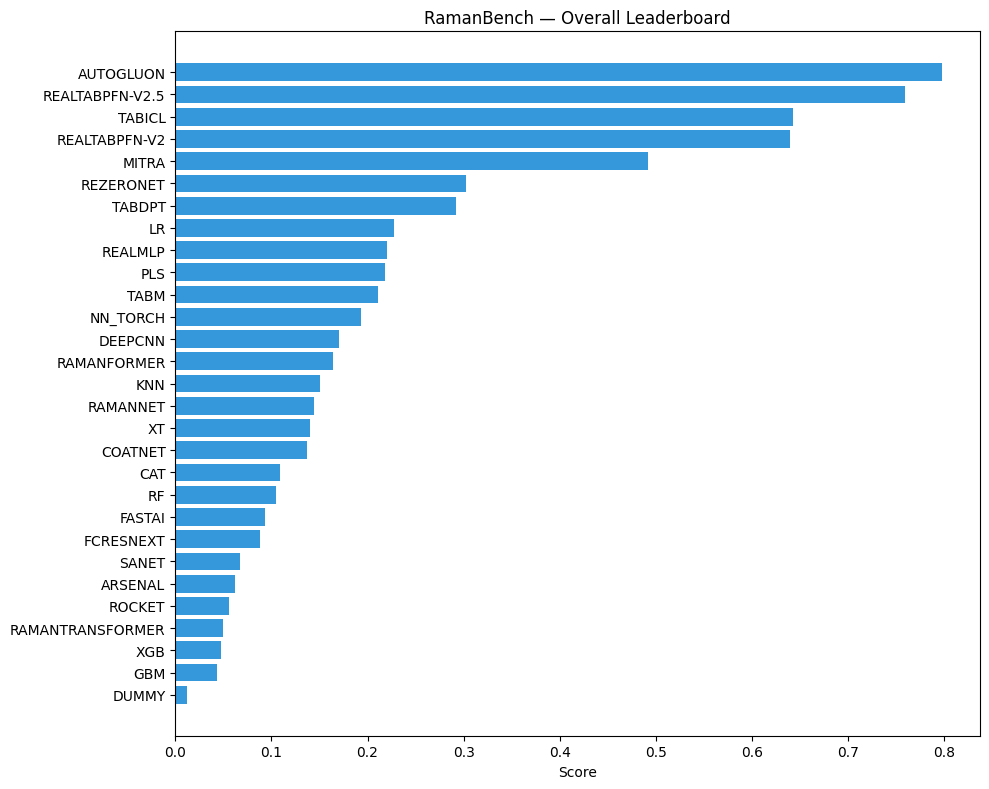

In [8]:
import matplotlib.pyplot as plt

if "lb" in dir():
    fig = lb.plot(task="overall", n_top=29)
    plt.tight_layout()
    plt.show()
else:
    print("No leaderboard loaded — run the cell above after the benchmark completes.")

## 6 — Precomputed results (no cluster needed)

The paper's benchmark results are shipped with the package as precomputed baselines so
that anyone can explore the leaderboard, reproduce figures, and compare new models without
running the cluster.  The cells above (sections 3–5) show how those CSVs were produced.

See **[notebook 02](02_benchmark_new_model.ipynb)** for a full walkthrough of adding a
new model to the leaderboard using only a standard `pip install raman-bench`.

In [9]:
from raman_bench import Leaderboard

lb = Leaderboard.from_precomputed()
print("Loaded precomputed leaderboard")
lb.rank().head(10)

2026-04-28 10:53:32,306 INFO raman_bench.leaderboard:from_precomputed:136: Loaded precomputed leaderboard: 10449 regression rows, 1827 classification rows


Loaded precomputed leaderboard


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7974,3.9,20.3,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7594,4.3,24.1,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443.0,0.6430,5.7,35.7,39.9,130.3
3,4,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6397,6.3,36.0,77.6,146.4
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.4923,8.1,50.8,827.4,626.5
5,6,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.3023,11.9,69.8,44.6,23.1
6,7,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2920,11.9,70.8,12.3,80.2
7,8,LR,Logistic Reg.,Traditional ML,1002.0,0.2279,15.1,77.2,37.2,41.2
8,9,REALMLP,RealMLP,Deep Learning,1111.0,0.2198,13.1,78.0,1935.5,71.1
9,10,PLS,PLS,Traditional ML,1004.0,0.2180,15.4,78.2,29.7,19.2
